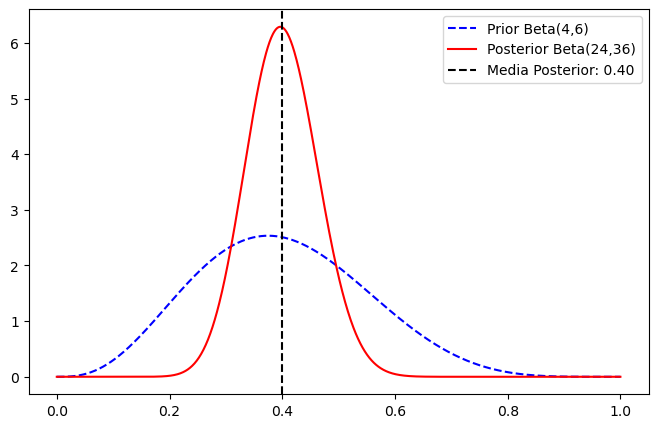

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

alphaprior = 4
betaprior = 6
x_observados = 20
n_total = 50
alphapost = alphaprior + x_observados
betapost = betaprior + (n_total - x_observados)
pval = np.linspace(0, 1, 1000)
prior= stats.beta.pdf(pval, alphaprior, betaprior)
posterior= stats.beta.pdf(pval, alphapost, betapost)
media=alphapost/(alphapost + betapost)
plt.figure(figsize=(8,5))
plt.plot(pval, prior, label=f'Prior Beta({alphaprior},{betaprior})', color='blue', linestyle='dashed')
plt.plot(pval, posterior, label=f'Posterior Beta({alphapost},{betapost})', color='red')
plt.axvline(x=media, linestyle='dashed', color='black', label=f'Media Posterior: {media:.2f}')
plt.legend()
plt.show()


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

np.random.seed(42)
mu_real = 5   
sigma = 2     
n = 200       
datos = stats.norm.rvs(loc=mu_real, scale=sigma, size=n, random_state=42)

mu_0 = 4      
tau2 = 1     #a priori


def verosim(mu, datos, sigma):
    return np.prod(stats.norm.pdf(datos, loc=mu, scale=sigma))


def posterior(mu, datos, sigma, mu_0, tau2):
    prior = stats.norm.pdf(mu, loc=mu_0, scale=np.sqrt(tau2))
    verosim_val = verosim(mu, datos, sigma)
    return prior * verosim_val

def metropolis_hastings(datos, sigma, mu_0, tau2, n_iter=20000, mu_ini=5, proposal_width=0.2):
    mu_actual = mu_ini
    posterior_vals = []
    
    for _ in range(n_iter):
        mu_propuesto = stats.norm.rvs(loc=mu_actual, scale=proposal_width)
        
        p_actual = posterior(mu_actual, datos, sigma, mu_0, tau2)
        p_propuesto = posterior(mu_propuesto, datos, sigma, mu_0, tau2)
        alpha = min(1, p_propuesto / p_actual)
        
        if stats.uniform.rvs() < alpha:  
            mu_actual = mu_propuesto
        
        posterior_vals.append(mu_actual)
        
    return np.array(posterior_vals)
        

samples = metropolis_hastings(datos, sigma, mu_0, tau2, n_iter=20000)

burn_in = 5000
samples_burned = samples[burn_in:]

mu_posterior_promedio = np.mean(samples_burned)
mu_posterior_standar = np.std(samples_burned)

print(mu_posterior_promedio)
print(mu_posterior_standar)


4.903381327012061
0.1394363206246456


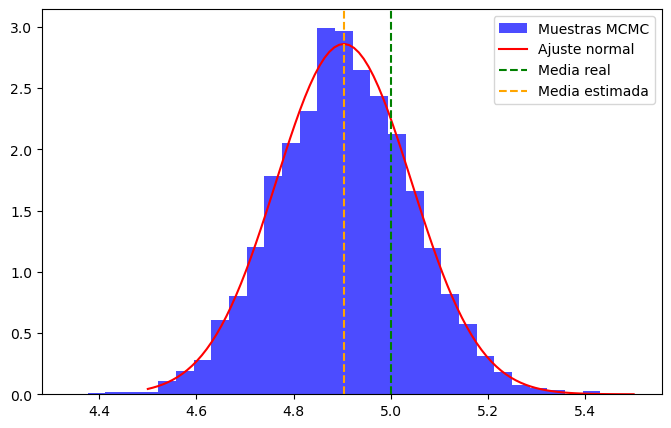

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(samples_burned, bins=30, density=True, alpha=0.7, color='blue', label="Muestras MCMC")

x = np.linspace(mu_real - 0.5, mu_real + 0.5, 100)
plt.plot(x, stats.norm.pdf(x, loc=mu_posterior_promedio, scale=mu_posterior_standar), 'r-', label="Ajuste normal")

plt.axvline(mu_real, color='g', linestyle='dashed', label="Media real")
plt.axvline(mu_posterior_promedio, color='orange', linestyle='dashed', label="Media estimada")
plt.legend()
plt.show()